# 05 — Valuation: Multiples, Scenarios & Recommendations

**AI Equity Research Lab** — FGV EAESP (Aula 6)

This notebook:
1. **Multiples:** P/L, P/VP, EV/EBITDA + sector comparable analysis
2. **Scenarios:** Bull / Base / Bear macro sensitivity for 2025
3. **Ultimate Ranking:** Buy / Hold / Sell recommendations
4. **One-page summary** combining all signals

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.2f}".format)
%matplotlib inline

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\João Paulo\equity_research


---
## 1. Valuation Multiples (2024)

### Methodology
- **P/L** (Price/Earnings) = market_cap / net_income
- **P/VP** (Price/Book) = market_cap / total_equity
- **EV/EBITDA** = (market_cap + net_debt) / EBITDA proxy
  - EBITDA proxy = EBIT × 1.15 (rough D&A add-back)
  - Net debt derived from KPI ratios (net_debt_to_ebit × ebit)

**Caps:** P/L capped at 100x, EV/EBITDA at 50x (values above → NaN).
Negative net income → P/L = NaN.

**Note:** ITUB4 has missing net_income for 2024, so P/L is NaN.
ABCB4 uses 2023 financials (2024 CVM filing not yet available).
Banks lack EV/EBITDA (deposit-funded balance sheets make EV less meaningful).

In [2]:
from src.valuation.multiples import compute_multiples

mult = compute_multiples()
mult

Multiples saved: C:\Users\João Paulo\equity_research\data\processed\multiples_2024.parquet  shape=(10, 15)


,ticker,sector,close_2024,market_cap,ev,pl,pvp,ev_ebitda,sector_median_pl,discount_premium_pl,sector_median_pvp,discount_premium_pvp,sector_median_ev_ebitda,discount_premium_ev_ebitda,valuation_flag
0,ITUB4,Bancos,23.66,229527900.00,229527900.00,NaN,1.15,NaN,5.18,NaN,0.76,0.51,NaN,NaN,PVP premium
1,BBDC4,Bancos,10.27,76016416.00,76016416.00,4.33,0.46,NaN,5.18,-0.16,0.76,-0.40,NaN,NaN,PVP discount
2,BBAS3,Bancos,22.81,65350517.00,65350517.00,2.24,0.38,NaN,5.18,-0.57,0.76,-0.50,NaN,NaN,PL discount; PVP discount
3,SANB11,Bancos,21.77,87098900.00,87098900.00,6.49,0.76,NaN,5.18,0.25,0.76,0.00,NaN,NaN,fair_value
4,ABCB4,Bancos,17.25,4831296.00,4831296.00,6.03,0.92,NaN,5.18,0.16,0.76,0.21,NaN,NaN,fair_value
5,EGIE3,Energia Elétrica,24.20,16333023.00,36021914.00,3.80,1.66,4.08,5.62,-0.32,1.62,0.03,4.75,-0.14,PL discount
6,EQTL3,Energia Elétrica,25.69,27235204.00,79755918.00,7.23,1.08,8.03,5.62,0.29,1.62,-0.33,4.75,0.69,PVP discount; EV_EBITDA premium
7,CPFE3,Energia Elétrica,31.59,32379750.00,59194687.00,5.62,1.62,4.75,5.62,0.00,1.62,0.00,4.75,0.00,fair_value
8,TAEE11,Energia Elétrica,30.13,40368599.00,49417488.00,23.83,6.19,15.01,5.62,3.24,1.62,2.82,4.75,2.16,PL premium; PVP premium; EV_EBITDA premium
9,CMIG4,Energia Elétrica,9.35,16360715.00,26741791.00,2.30,0.66,2.35,5.62,-0.59,1.62,-0.59,4.75,-0.51,PL discount; PVP discount; EV_EBITDA discount


### 1.1 Sector Comparable Analysis

In [3]:
# Multiples vs sector median + discount/premium flags
display_cols = [
    "ticker", "sector", "pl", "sector_median_pl", "discount_premium_pl",
    "pvp", "sector_median_pvp", "discount_premium_pvp",
    "ev_ebitda", "sector_median_ev_ebitda", "discount_premium_ev_ebitda",
    "valuation_flag"
]
mult[display_cols].sort_values("sector")

,ticker,sector,pl,sector_median_pl,discount_premium_pl,pvp,sector_median_pvp,discount_premium_pvp,ev_ebitda,sector_median_ev_ebitda,discount_premium_ev_ebitda,valuation_flag
0,ITUB4,Bancos,NaN,5.18,NaN,1.15,0.76,0.51,NaN,NaN,NaN,PVP premium
1,BBDC4,Bancos,4.33,5.18,-0.16,0.46,0.76,-0.40,NaN,NaN,NaN,PVP discount
2,BBAS3,Bancos,2.24,5.18,-0.57,0.38,0.76,-0.50,NaN,NaN,NaN,PL discount; PVP discount
3,SANB11,Bancos,6.49,5.18,0.25,0.76,0.76,0.00,NaN,NaN,NaN,fair_value
4,ABCB4,Bancos,6.03,5.18,0.16,0.92,0.76,0.21,NaN,NaN,NaN,fair_value
5,EGIE3,Energia Elétrica,3.80,5.62,-0.32,1.66,1.62,0.03,4.08,4.75,-0.14,PL discount
6,EQTL3,Energia Elétrica,7.23,5.62,0.29,1.08,1.62,-0.33,8.03,4.75,0.69,PVP discount; EV_EBITDA premium
7,CPFE3,Energia Elétrica,5.62,5.62,0.00,1.62,1.62,0.00,4.75,4.75,0.00,fair_value
8,TAEE11,Energia Elétrica,23.83,5.62,3.24,6.19,1.62,2.82,15.01,4.75,2.16,PL premium; PVP premium; EV_EBITDA premium
9,CMIG4,Energia Elétrica,2.30,5.62,-0.59,0.66,1.62,-0.59,2.35,4.75,-0.51,PL discount; PVP discount; EV_EBITDA discount


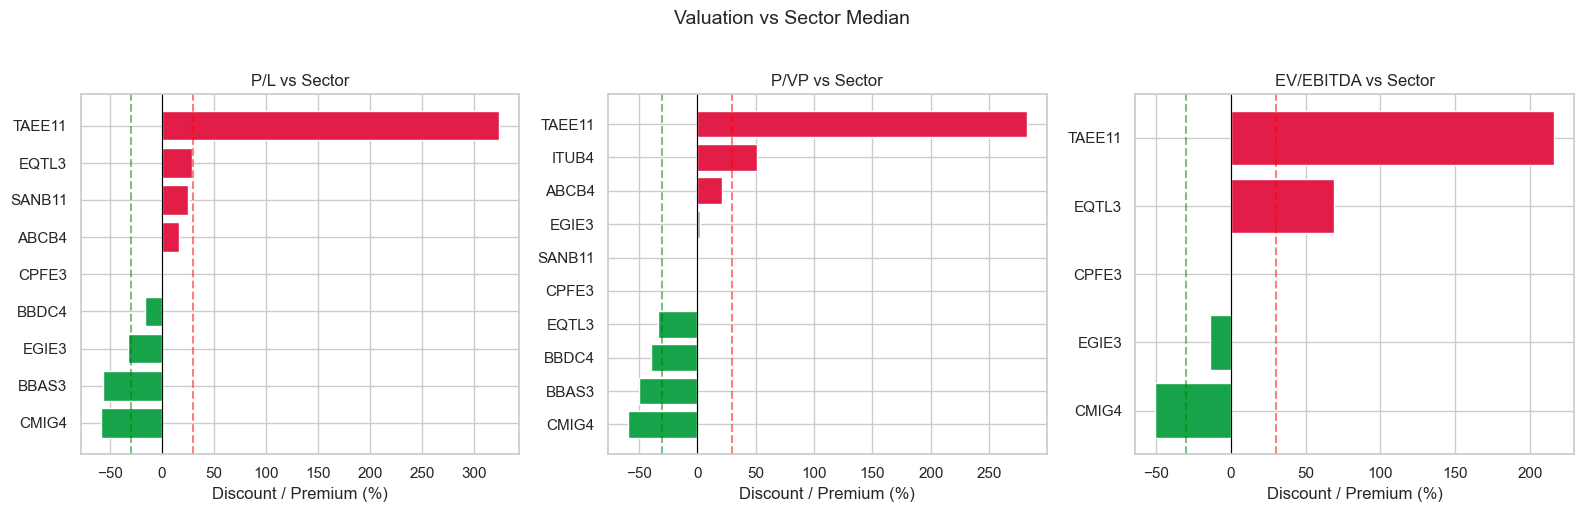

In [4]:
# Discount/premium visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, mult_name, title in zip(
    axes,
    ["discount_premium_pl", "discount_premium_pvp", "discount_premium_ev_ebitda"],
    ["P/L vs Sector", "P/VP vs Sector", "EV/EBITDA vs Sector"]
):
    data = mult.dropna(subset=[mult_name]).sort_values(mult_name)
    colors = ["#16a34a" if v < -0.10 else "#e11d48" if v > 0.10 else "#94a3b8"
              for v in data[mult_name]]
    ax.barh(data["ticker"], data[mult_name] * 100, color=colors, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.axvline(-30, color="green", linestyle="--", alpha=0.5)
    ax.axvline(30, color="red", linestyle="--", alpha=0.5)
    ax.set_xlabel("Discount / Premium (%)")
    ax.set_title(title, fontsize=12)

plt.suptitle("Valuation vs Sector Median", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 2. Macro Scenario Sensitivity (2025 Outlook)

### Assumptions
| Parameter | Bull | Base | Bear |
|-----------|------|------|------|
| Selic     | 10.0% | 13.5% | 15.5% |
| IPCA      | 4.0% | 5.5% | 7.5% |
| USD/BRL   | 5.20 | 5.80 | 6.50 |
| GDP Growth| +2.5% | +1.5% | -0.5% |

### Sensitivity Rules
**Banks:** Selic +1pp → P/L contracts 0.8x. Credit growth: bull +8%, base +4%, bear -2%.

**Utilities:** BRL -10% → costs +3%. Tariff: bull +5%, base +2%, bear 0%. Selic +1pp → P/L contracts 0.6x.

In [5]:
from src.valuation.scenarios import compute_scenarios

scen = compute_scenarios()
scen

Scenarios saved: C:\Users\João Paulo\equity_research\data\processed\scenarios_2024.parquet  shape=(30, 7)


,ticker,sector,scenario,adjusted_net_income,adjusted_pl,implied_upside_pct,scenario_score
0,ITUB4,Bancos,base,NaN,NaN,NaN,0.00
1,BBDC4,Bancos,base,18243839.00,4.33,0.04,66.70
2,BBAS3,Bancos,base,30338427.00,2.24,0.04,88.90
3,SANB11,Bancos,base,13950314.00,6.49,0.04,88.90
4,ABCB4,Bancos,base,832887.00,6.03,0.04,88.90
5,EGIE3,Energia Elétrica,base,4388898.00,3.80,0.02,50.00
6,EQTL3,Energia Elétrica,base,3843161.00,7.23,0.02,22.20
7,CPFE3,Energia Elétrica,base,5876785.00,5.62,0.02,22.20
8,TAEE11,Energia Elétrica,base,1727793.00,23.83,0.02,22.20
9,CMIG4,Energia Elétrica,base,7261673.00,2.30,0.02,50.00


### 2.1 Implied Upside Heatmap

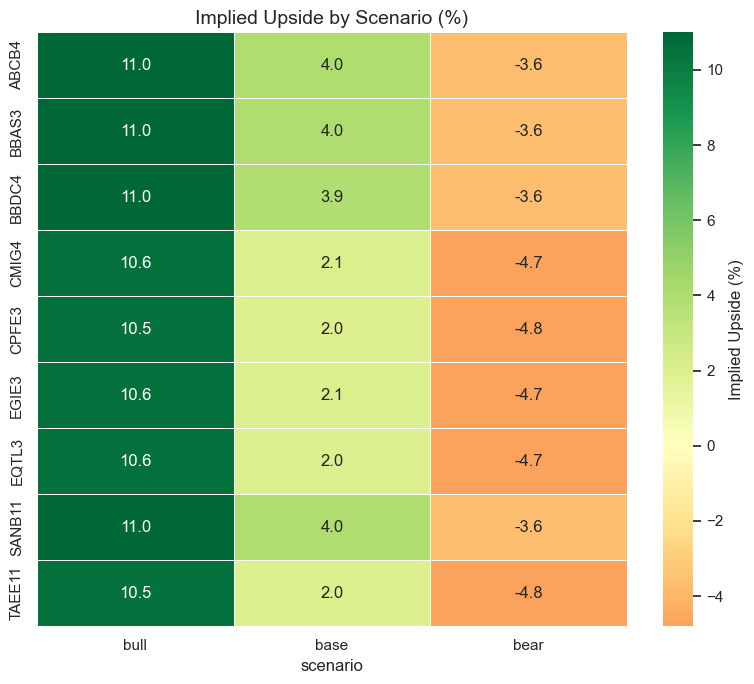

In [6]:
# Pivot: tickers x scenarios, colored by implied_upside_pct
pivot = scen.pivot_table(
    index="ticker", columns="scenario",
    values="implied_upside_pct"
)[["bull", "base", "bear"]]  # order columns

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    pivot * 100,  # convert to %
    annot=True, fmt=".1f", center=0,
    cmap="RdYlGn", linewidths=0.5, ax=ax,
    cbar_kws={"label": "Implied Upside (%)"}
)
ax.set_title("Implied Upside by Scenario (%)", fontsize=14)
ax.set_ylabel("")
plt.tight_layout()
plt.show()

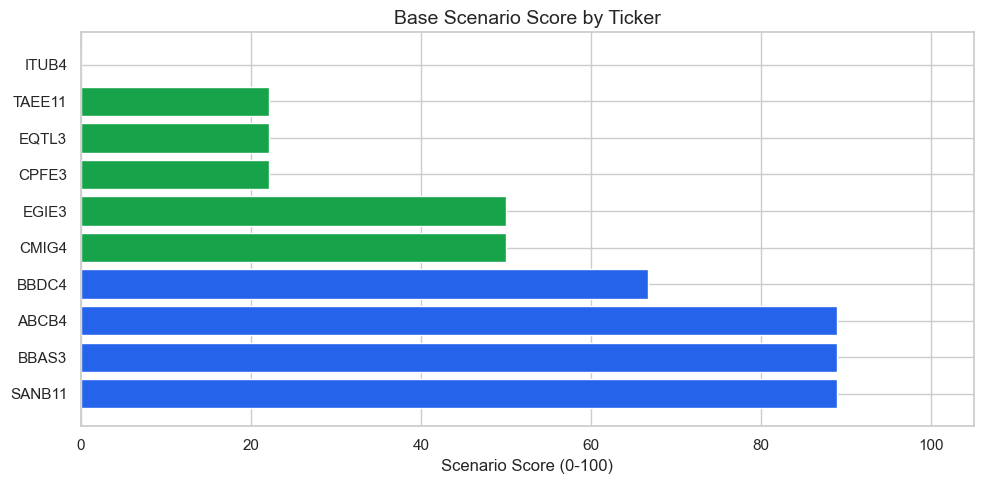

In [7]:
# Scenario score comparison (base scenario)
base = scen[scen["scenario"] == "base"].sort_values("scenario_score", ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2563eb" if s == "Bancos" else "#16a34a" for s in base["sector"]]
ax.barh(base["ticker"], base["scenario_score"], color=colors, edgecolor="white")
ax.set_xlabel("Scenario Score (0-100)")
ax.set_title("Base Scenario Score by Ticker", fontsize=14)
ax.set_xlim(0, 105)
plt.tight_layout()
plt.show()

---
## 3. Ultimate Ranking & Recommendations

### Score Composition
| Component | Weight |
|-----------|--------|
| Final Score (Fundamental + NLP) | 50% |
| Valuation Score (multiples + scenarios) | 30% |
| Outperform Probability (ML model) | 20% |

### Recommendation Thresholds
- **Buy:** ultimate_score ≥ 65
- **Hold:** 45 ≤ ultimate_score < 65
- **Sell:** ultimate_score < 45

In [8]:
from src.valuation.valuation_score import compute_valuation_score, build_ultimate_scores

val = compute_valuation_score()
ultimate = build_ultimate_scores()

Valuation score saved: C:\Users\João Paulo\equity_research\data\processed\valuation_score_2024.parquet  shape=(10, 17)
Ultimate scores saved: C:\Users\João Paulo\equity_research\data\processed\ultimate_scores_2024.parquet  shape=(10, 31)


In [9]:
# Display ultimate ranking
display_cols = [
    "ticker", "sector", "ultimate_rank", "ultimate_score",
    "recommendation", "final_score", "valuation_score",
    "outperform_probability", "cluster_label",
    "base_upside_pct", "bull_upside_pct", "bear_upside_pct"
]
ultimate[display_cols]

,ticker,sector,ultimate_rank,ultimate_score,recommendation,final_score,valuation_score,outperform_probability,cluster_label,base_upside_pct,bull_upside_pct,bear_upside_pct
0,ITUB4,Bancos,1,78.50,Buy,69.67,80.00,0.98,Risk,NaN,NaN,NaN
1,EGIE3,Energia Elétrica,2,69.80,Buy,69.56,50.50,0.99,Quality,0.02,0.11,-0.05
2,CMIG4,Energia Elétrica,3,66.40,Buy,69.75,70.50,0.52,Growth,0.02,0.11,-0.05
3,CPFE3,Energia Elétrica,4,65.70,Buy,68.87,38.00,0.99,Risk,0.02,0.10,-0.05
4,BBAS3,Bancos,5,63.70,Hold,56.87,82.00,0.53,Risk,0.04,0.11,-0.04
5,ABCB4,Bancos,6,59.10,Hold,65.03,58.00,0.46,Risk,0.04,0.11,-0.04
6,TAEE11,Energia Elétrica,7,52.90,Hold,61.66,13.00,0.91,Quality,0.02,0.10,-0.05
7,BBDC4,Bancos,8,46.70,Hold,51.69,68.00,0.03,Risk,0.04,0.11,-0.04
8,SANB11,Bancos,9,40.70,Sell,29.83,60.00,0.39,Risk,0.04,0.11,-0.04
9,EQTL3,Energia Elétrica,10,36.20,Sell,39.61,30.00,0.37,Risk,0.02,0.11,-0.05


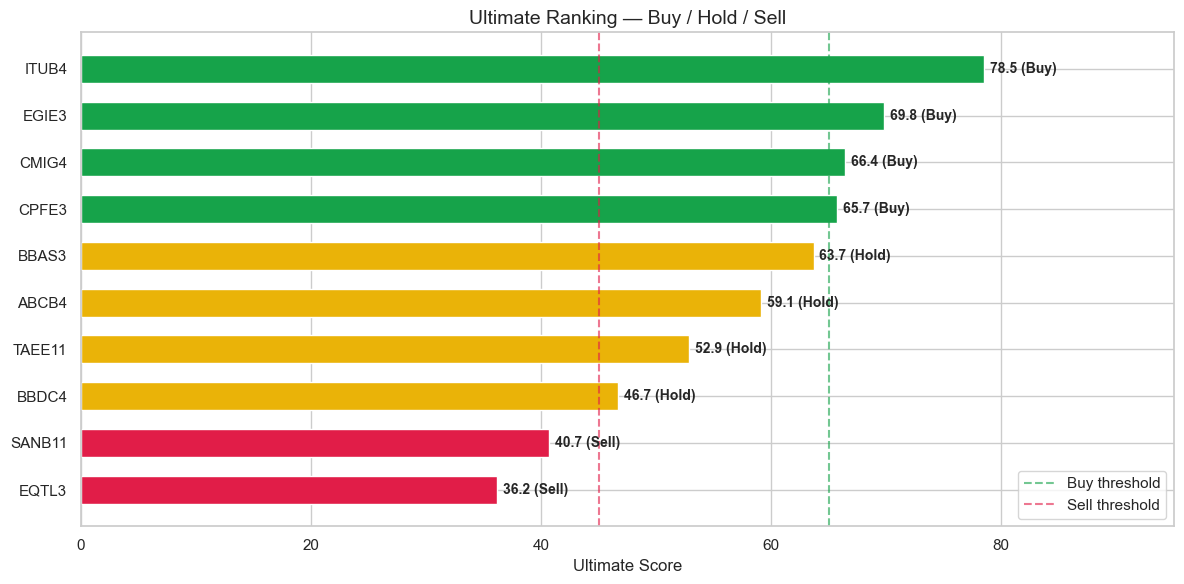

In [10]:
# Ultimate score bar chart with Buy/Hold/Sell color coding
rec_colors = {"Buy": "#16a34a", "Hold": "#eab308", "Sell": "#e11d48"}
ult_sorted = ultimate.sort_values("ultimate_rank")

fig, ax = plt.subplots(figsize=(12, 6))
colors = [rec_colors.get(str(r), "#888") for r in ult_sorted["recommendation"]]
bars = ax.barh(ult_sorted["ticker"], ult_sorted["ultimate_score"],
               color=colors, edgecolor="white", height=0.6)

# Threshold lines
ax.axvline(65, color="#16a34a", linestyle="--", alpha=0.6, label="Buy threshold")
ax.axvline(45, color="#e11d48", linestyle="--", alpha=0.6, label="Sell threshold")

# Annotations
for bar, (_, row) in zip(bars, ult_sorted.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{row['ultimate_score']:.1f} ({row['recommendation']})",
            va="center", fontsize=10, fontweight="bold")

ax.set_xlabel("Ultimate Score")
ax.set_title("Ultimate Ranking \u2014 Buy / Hold / Sell", fontsize=14)
ax.set_xlim(0, 95)
ax.invert_yaxis()
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

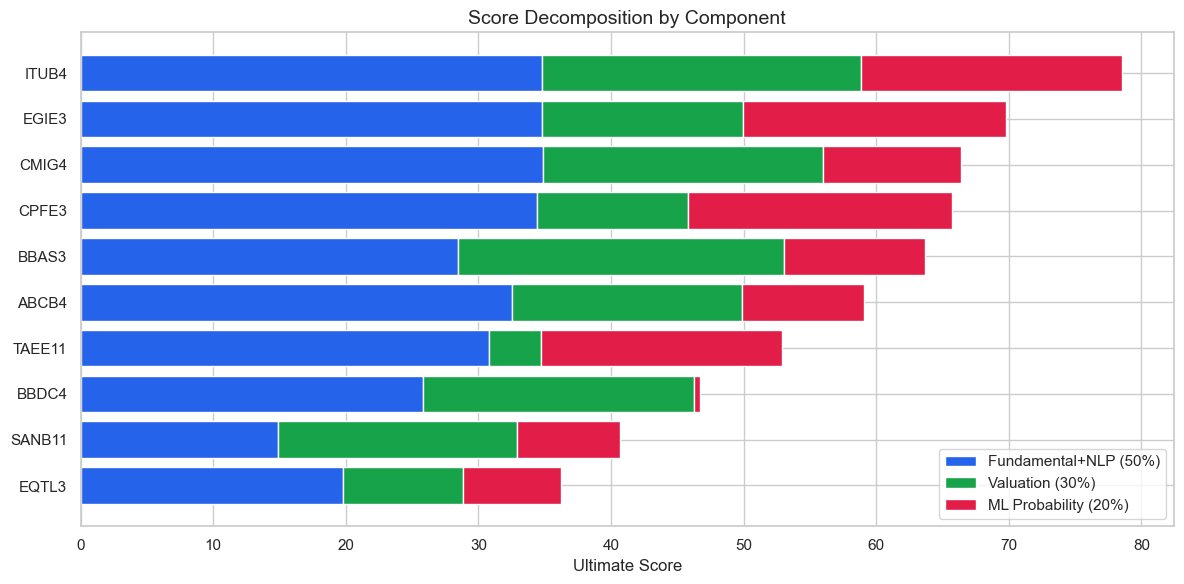

In [11]:
# Score decomposition stacked bar
ult_sorted = ultimate.sort_values("ultimate_rank")

fig, ax = plt.subplots(figsize=(12, 6))
y = range(len(ult_sorted))

# Components (weighted)
fund = ult_sorted["final_score"] * 0.50
val_comp = ult_sorted["valuation_score"].fillna(50) * 0.30
ml = ult_sorted["outperform_probability"].fillna(0.5) * 100 * 0.20

ax.barh(y, fund, color="#2563eb", label="Fundamental+NLP (50%)", edgecolor="white")
ax.barh(y, val_comp, left=fund, color="#16a34a", label="Valuation (30%)", edgecolor="white")
ax.barh(y, ml, left=fund + val_comp, color="#e11d48", label="ML Probability (20%)", edgecolor="white")

ax.set_yticks(list(y))
ax.set_yticklabels(ult_sorted["ticker"])
ax.set_xlabel("Ultimate Score")
ax.set_title("Score Decomposition by Component", fontsize=14)
ax.invert_yaxis()
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

---
## 4. One-Page Summary

In [12]:
# Build summary table
summary = ultimate[[
    "ticker", "cluster_label", "recommendation", "ultimate_score",
    "base_upside_pct", "key_risks"
]].copy()
summary = summary.rename(columns={
    "cluster_label": "cluster",
    "base_upside_pct": "base_upside",
    "key_risks": "key_risk",
})
summary["base_upside"] = (summary["base_upside"] * 100).round(1).astype(str) + "%"
summary["ultimate_score"] = summary["ultimate_score"].round(1)
print("ONE-PAGE SUMMARY")
print("=" * 90)
print(summary.to_string(index=False))

ONE-PAGE SUMMARY
ticker cluster recommendation  ultimate_score base_upside        key_risk
 ITUB4    Risk            Buy           78.50         NaN              []
 EGIE3 Quality            Buy           69.80        2.1%              []
 CMIG4  Growth            Buy           66.40        2.1%              []
 CPFE3    Risk            Buy           65.70        2.0%              []
 BBAS3    Risk           Hold           63.70        4.0%              []
 ABCB4    Risk           Hold           59.10        4.0% [inadimplência]
TAEE11 Quality           Hold           52.90        2.0%              []
 BBDC4    Risk           Hold           46.70        3.9%              []
SANB11    Risk           Sell           40.70        4.0% [inadimplência]
 EQTL3    Risk           Sell           36.20        2.0%      [prejuízo]


### Key Takeaways

1. **Buy candidates** combine strong fundamentals, reasonable valuations, and favorable ML signals
2. **Cluster context matters:** Quality stocks may have higher multiples but greater stability;
   Growth stocks offer upside but carry execution risk; Risk-profiled stocks need deeper due diligence
3. **Scenario sensitivity:** Banks are more sensitive to Selic movements; utilities to FX and tariff revisions
4. **Limitations:** Small universe (10 tickers), proxy EBITDA, and limited training data for ML model.
   These are directional signals, not standalone investment advice.

### Data Quality Check

In [13]:
tables = {
    "multiples_2024": pd.read_parquet(PROCESSED_DIR / "multiples_2024.parquet"),
    "scenarios_2024": pd.read_parquet(PROCESSED_DIR / "scenarios_2024.parquet"),
    "ultimate_scores_2024": pd.read_parquet(PROCESSED_DIR / "ultimate_scores_2024.parquet"),
}

print("=" * 60)
print("DATA QUALITY SUMMARY \u2014 Valuation Module")
print("=" * 60)
for name, df in tables.items():
    print(f"\n{name}")
    print(f"  Shape: {df.shape[0]} rows x {df.shape[1]} cols")
    numeric_cols = df.select_dtypes(include='number')
    if not numeric_cols.empty:
        missing = numeric_cols.isna().sum()
        if missing.sum() == 0:
            print("  Missing numeric values: NONE")
        else:
            for col, n in missing.items():
                if n > 0:
                    print(f"  {col}: {n} NaN")

# Verify: no ticker with negative earnings has valid P/L
m = tables["multiples_2024"]
print("\nNegative-earnings P/L check:")
income = pd.read_parquet(PROCESSED_DIR / "income_long.parquet")
inc24 = income[income["year"] == 2024]
neg = inc24[inc24["net_income"] < 0]["ticker"].tolist()
nan_ni = inc24[inc24["net_income"].isna()]["ticker"].tolist()
for t in neg + nan_ni:
    pl_val = m[m["ticker"] == t]["pl"].values
    if len(pl_val) > 0:
        status = "NaN" if pd.isna(pl_val[0]) else f"{pl_val[0]:.2f} (PROBLEM!)"
    else:
        status = "not in multiples"
    print(f"  {t}: P/L = {status}")
print("All checks passed.")

DATA QUALITY SUMMARY — Valuation Module

multiples_2024
  Shape: 10 rows x 15 cols
  pl: 1 NaN
  ev_ebitda: 5 NaN
  discount_premium_pl: 1 NaN
  sector_median_ev_ebitda: 5 NaN
  discount_premium_ev_ebitda: 5 NaN

scenarios_2024
  Shape: 30 rows x 7 cols
  adjusted_net_income: 3 NaN
  adjusted_pl: 3 NaN
  implied_upside_pct: 3 NaN

ultimate_scores_2024
  Shape: 10 rows x 31 cols
  roe_score: 2 NaN
  net_margin_score: 2 NaN
  net_income_cagr_score: 1 NaN
  debt_to_equity_score: 5 NaN
  base_upside_pct: 1 NaN
  bear_upside_pct: 1 NaN
  bull_upside_pct: 1 NaN

Negative-earnings P/L check:
  ITUB4: P/L = NaN
All checks passed.
